# Noncollinear magnetism, magnetic fields and constrained moments

With `nspin_mag = 4` the magnetization is a **vector field**, not a number per point. Two
things follow. The symmetry group shrinks — a rotation must map the moments onto
themselves as an *axial* vector, carrying $\det(R)$, and some operations survive only
combined with time reversal. And there is a direction to constrain or to push on, which
is what magnetic fields and constrained moments are for.

bcc iron matches Quantum ESPRESSO to **2.8e-9 Ry** with LDA and with PBE; fields and all
of QE's constrained-moment schemes to **≤2e-7 Ry**. Phases P17 and P18.

In [1]:
from pathlib import Path

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from pypresso.io import read_qe_output
from pypresso.io.pwin import parse_pw_input, read_pw_input
from pypresso.pseudo import read_upf
from pypresso.scf import run_scf
from pypresso.scf.driver import Calculation
from pypresso.scf.fields import MagneticField
from pypresso.scf.locals import LocalRegions
from pypresso.system import build_system
from pypresso.system.builder import local_moments
from pypresso.system.symmetry import find_symmetries, magnetic_symmetries

NONCOLIN = Path("../quantum_espresso/qe-7.5-ReleasePack/qe-7.5/test-suite/pw_noncolin")
PSEUDO, GENERATED = Path("../tests/data/pseudo"), Path("../tests/data/qe")


def load(text):
    system = build_system(parse_pw_input(text))
    return system, tuple(read_upf(PSEUDO / s.pseudo_file)
                         for s in system.structure.species)


def scf(text, **options):
    system, pseudos = load(text)
    pwin = parse_pw_input(text)
    options.setdefault("conv_thr", 1e-10)
    options.setdefault("max_iterations", 200)
    options.setdefault("mixing_beta", float(pwin.get("electrons", "mixing_beta") or 0.7))
    return system, run_scf(system, pseudos, **options)


def namelist(text, extra):
    marker = text.lower().index("&system") + len("&system")
    return text[:marker] + "\n" + extra + text[marker:]


# The references are regenerated with the vendored pw.x: the shipped 2017 output of
# noncolin-constrain_atomic.in does not belong to the input beside it.
text = (NONCOLIN / "noncolin.in").read_text()
system, _ = load(text)
full = find_symmetries(system.cell, system.structure)
moments = local_moments(system.structure, 4, system.starting_magnetization,
                        system.angle1, system.angle2)
magnetic = magnetic_symmetries(system.cell, system.structure, full, moments)
reference = read_qe_output(GENERATED / "reference.out.pw_noncolin-noncolin")

print("starting moment       %s" % np.round(moments[0], 4))
print("crystal point group   %d operations" % full.nsym)
print("magnetic group        %d operations (%d of them needing time reversal)"
      % (magnetic.nsym, sum(magnetic.time_reversed)))
print("k-points: input %d -> pypresso %d, QE %d"
      % (len(read_pw_input(NONCOLIN / "noncolin.in").card("K_POINTS").lines) - 1,
         system.kpoints.nk, len(reference.kpoints)))

starting moment       [0.5 0.  0. ]
crystal point group   48 operations
magnetic group        16 operations (8 of them needing time reversal)
k-points: input 11 -> pypresso 22, QE 22


## The identity that gates the regime

A noncollinear run whose moments all point along $z$ **is** the collinear run, and
turning them all together must change nothing at all. A hydrogen atom, its moment placed
along four different directions:

In [2]:
base = (GENERATED / "h-atom-lsda.in").read_text()
directions = {"z": (0.0, 0.0), "x": (90.0, 0.0), "y": (90.0, 90.0),
              "(1,1,1)": (54.7356103172, 45.0)}
energies, vectors = {}, {}
for label, (theta, phi) in directions.items():
    _, result = scf(base.replace(
        "    nspin = 2",
        "    noncolin = .true.\n    angle1(1) = %s, angle2(1) = %s" % (theta, phi)))
    energies[label] = result.total_energy
    vectors[label] = np.asarray(result.magnetization_vector)
_, collinear = scf(base)

print("%-12s %20s   moment (mu_B)" % ("moment along", "total energy (Ry)"))
for label, energy in energies.items():
    print("%-12s %20.12f   %s" % (label, energy, np.round(vectors[label], 4)))
print("%-12s %20.12f   %.4f (along z by construction)"
      % ("collinear", collinear.total_energy, collinear.magnetization))
print("\nspread over the four directions    %.1e Ry"
      % (max(energies.values()) - min(energies.values())))
print("noncollinear along z vs collinear  %.1e Ry"
      % abs(energies["z"] - collinear.total_energy))

moment along    total energy (Ry)   moment (mu_B)
z                 -0.946064951880   [ 0. -0.  1.]
x                 -0.946064951862   [1. 0. 0.]
y                 -0.946064951904   [0. 1. 0.]
(1,1,1)           -0.946064951911   [0.5774 0.5774 0.5774]
collinear         -0.946064951854   1.0000 (along z by construction)

spread over the four directions    4.9e-11 Ry
noncollinear along z vs collinear  2.6e-11 Ry


This identity is what found a 129 Ry bug: nothing else in the regime has an answer known
in advance.

## bcc iron, against Quantum ESPRESSO

LDA first, then PBE — which needs `gradcorr` run in the **local spin frame**, rotating the
vector density onto its own axis at each point, taking the collinear gradient correction
there, and rotating the potential back.

In [3]:
system, iron = scf(text)
print("%-16s %18s %18s %12s" % ("term", "pypresso", "QE", "difference"))
for term, value in reference.energy_terms.items():
    if term in iron.energy_terms:
        print("%-16s %18.8f %18.8f %12.2e"
              % (term, iron.energy_terms[term], value,
                 abs(iron.energy_terms[term] - value)))
print("%-16s %18.8f %18.8f %12.2e"
      % ("TOTAL", iron.total_energy, reference.total_energy,
         abs(iron.total_energy - reference.total_energy)))
print("moment  pypresso %s   QE %s"
      % (np.round(iron.magnetization_vector, 4), reference.magnetization_vector))

_, iron_pbe = scf((NONCOLIN / "noncolin-pbe.in").read_text())
reference_pbe = read_qe_output(GENERATED / "reference.out.pw_noncolin-noncolin-pbe")
print("\nPBE     pypresso %.9f Ry   QE %.9f Ry   difference %.1e"
      % (iron_pbe.total_energy, reference_pbe.total_energy,
         abs(iron_pbe.total_energy - reference_pbe.total_energy)))
print("        moment %.2f -> %.2f mu_B, which is why a magnetic comparison with the "
      "literature needs the gradient correction"
      % (np.linalg.norm(iron.magnetization_vector),
         np.linalg.norm(iron_pbe.magnetization_vector)))

/tmp/ipykernel_2423469/417838658.py:34: RuntimeWarning: tstress = .true. in the input, but forces and stress for a noncollinear or spin-orbit calculation are not implemented; nspin = 1 and nspin = 2 are, on norm-conserving, ultrasoft and PAW pseudopotentials. The SCF is unaffected and SCFResult.stress is None.
  return system, run_scf(system, pseudos, **options)


term                       pypresso                 QE   difference
one-electron             8.92933178         8.92932731     4.47e-06
hartree                  6.13361506         6.13359228     2.28e-05
xc                     -26.12190861       -26.12188165     2.70e-05
ewald                  -44.64461207       -44.64461207     4.30e-09
smearing                 0.00388950         0.00388979     2.94e-07
TOTAL                  -55.69968434       -55.69968434     2.78e-09
moment  pypresso [ 3.1763 -0.      0.    ]   QE (3.18, -0.0, -0.0)



PBE     pypresso -55.939445673 Ry   QE -55.939445670 Ry   difference 2.8e-09
        moment 3.18 -> 3.47 mu_B, which is why a magnetic comparison with the literature needs the gradient correction


"The moment on this atom" has no exact meaning without muffin tins: it is the
magnetization integrated over a sphere of QE's `r_m`, and about 60% of iron's valence
charge is inside it. What is reported is that integral, matching QE's.

## Constraints: the energy is written down and the potential is `jax.grad` of it

QE's `add_bfield.f90` carries five hand-derived potentials, one per constraint scheme.
Here the *penalty energy* is written down and its potential is the gradient — so QE's
algebra becomes a **test**, not a second implementation. Below: the atomic-direction
scheme, compared against `add_bfield`'s expression on a synthetic density.

In [4]:
rng = np.random.default_rng(20260820)
grid = (6, 5, 4)
rho = rng.normal(size=(4,) + grid) * 0.1
rho[0] = np.abs(rho[0]) + 0.5
weights = jnp.asarray(rng.uniform(size=(2,) + grid))
cosines, penalty = np.array([[0.3], [-0.6]]), 0.21

field = MagneticField(regions=LocalRegions(weights=weights, radii=(1.0,), scheme="qe"),
                      uniform=jnp.zeros(3), atomic=None, targets=jnp.asarray(cosines),
                      penalty=penalty, constraint="atomic direction")
v, _, _ = field.potential(jnp.asarray(rho), system.cell)

m_loc = np.asarray(field.local_moments(jnp.asarray(rho), system.cell))
m2 = np.zeros_like(m_loc)
for a in range(2):
    ma = np.linalg.norm(m_loc[a])
    xx = m_loc[a, 2] / ma - cosines[a, 0]
    m2[a, 0] = -xx * m_loc[a, 0] * m_loc[a, 2] / ma**3
    m2[a, 1] = -xx * m_loc[a, 1] * m_loc[a, 2] / ma**3
    m2[a, 2] = xx * (-m_loc[a, 2] ** 2 / ma**3 + 1.0 / ma)
qe_potential = 2.0 * penalty * np.einsum("anmk,ac->cnmk", np.asarray(weights), m2)

print("jax.grad against add_bfield's algebra: %.1e"
      % np.abs(np.asarray(v)[1:] - qe_potential).max())
print("the charge component is untouched:     %.1e" % np.abs(np.asarray(v)[0]).max())

print("\n%-18s %16s %16s %10s" % ("scheme", "pypresso (Ry)", "QE (Ry)", "difference"))
for name, scheme in (("noncolin-constrain_atomic.in", "atomic"),
                     ("noncolin-constrain_angle.in", "atomic direction"),
                     ("noncolin-constrain_total.in", "total")):
    _, result = scf((NONCOLIN / name).read_text(), conv_thr=1e-11)
    ref = read_qe_output(GENERATED / f"reference.out.pw_noncolin-{Path(name).stem}")
    print("%-18s %16.8f %16.8f %10.1e"
          % (scheme, result.total_energy, ref.total_energy,
             abs(result.total_energy - ref.total_energy)))

jax.grad against add_bfield's algebra: 2.2e-16
the charge component is untouched:     0.0e+00

scheme                pypresso (Ry)          QE (Ry) difference


atomic                 -55.69055703     -55.69055687    1.6e-07


atomic direction       -55.69968434     -55.69968434    2.7e-09


total                  -55.54266143     -55.54266124    1.9e-07


**The constraint's energy is not in the total energy.** `add_bfield` is called from
inside `v_of_rho`, so `deband` removes it again and `etcon` is printed separately; Elk
excludes its external field's energy by the same convention, and both numbers are carried
apart here for that reason.

## `reducebf`: a field whose job is to leave

Elk's trick for reaching a magnetic state a nonmagnetic start would never find: apply a
field, halve it every iteration, and let it vanish. The hydrogen atom started
unpolarized stays unpolarized forever; with a fading field it lands on the magnetic
answer to 1e-10 Ry, and a field left switched **on** does not — it is still there in the
potential.

run                               energy (Ry)    moment
started magnetic                 -0.946064952   1.00000
started nonmagnetic              -0.893648588   0.00000
nonmagnetic + fading field       -0.946064952   1.00000
nonmagnetic + field held on      -0.946014192   1.00000

the fading field lands on the magnetic answer to 5.6e-11 Ry; a field left on is 5.1e-05 Ry away


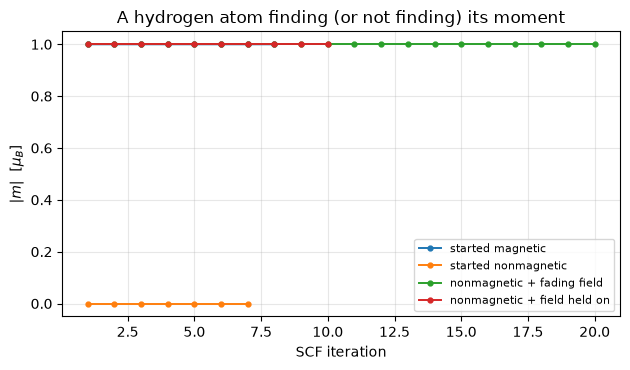

In [5]:
card = "LOCAL_MAGNETIC_FIELDS\n 0.0 0.0 0.10\n"
unmagnetised = base.replace("starting_magnetization(1) = 0.6",
                            "starting_magnetization(1) = 0.0")
runs = {}
_, runs["started magnetic"] = scf(base)
_, runs["started nonmagnetic"] = scf(unmagnetised)
_, runs["nonmagnetic + fading field"] = scf(
    namelist(unmagnetised, "    reducebf = 0.5\n") + card)
_, runs["nonmagnetic + field held on"] = scf(namelist(unmagnetised, "") + card)

print("%-30s %14s %9s" % ("run", "energy (Ry)", "moment"))
for label, result in runs.items():
    print("%-30s %14.9f %9.5f" % (label, result.total_energy, result.magnetization))
print("\nthe fading field lands on the magnetic answer to %.1e Ry; a field left on is "
      "%.1e Ry away"
      % (abs(runs["nonmagnetic + fading field"].total_energy
             - runs["started magnetic"].total_energy),
         abs(runs["nonmagnetic + field held on"].total_energy
             - runs["started magnetic"].total_energy)))

fig, ax = plt.subplots(figsize=(6.4, 3.8))
for label, result in runs.items():
    history = [abs(step["magnetization"]) for step in result.history]
    ax.plot(range(1, len(history) + 1), history, "o-", ms=3.5, lw=1.4, label=label)
ax.set_xlabel("SCF iteration"); ax.set_ylabel(r"$|m|$  [$\mu_B$]")
ax.set_title("A hydrogen atom finding (or not finding) its moment")
ax.legend(fontsize=8); ax.grid(alpha=0.3); fig.tight_layout()

## Fixing a moment instead of penalising it

A penalty leaves a residual force: the state sits where `lambda (m - m_fix)^2` balances the
functional, which is not a stationary point of the functional itself. Elk's fixed-spin-moment
scheme instead *searches* for the field at which the unconstrained functional puts the moment
where it was asked — so what converges is a genuine stationary state, and the field it found
is a result worth reading.

Searching is a control problem, and how it is done is worth more than a factor of ten.
Elk nudges the field after **every** SCF iteration, which reads a moment that has not
finished responding to the last nudge: it rings, and takes 1380 iterations here. At
converged density `m(B)` is smooth, so `fsm_update = 'secant'` holds the field until the
SCF has converged and then steps by the susceptibility it measures — the same answer in
**74**.

In [6]:
fsm = (GENERATED / "fe-fsm.in").read_text()
marker = fsm.index("&system") + len("&system")

print("%-8s %7s %14s %11s %17s"
      % ("rule", "iters", "B (Ry)", "m (mu_B)", "E (Ry)"))
for rule in ("secant", "elk"):
    source = fsm[:marker] + f"\n    fsm_update = '{rule}'\n" + fsm[marker:]
    _, result = scf(source, conv_thr=1e-8, max_iterations=2000)
    print("%-8s %7d %14.8f %11.6f %17.9f"
          % (rule, result.iterations, float(np.asarray(result.magnetic_field.uniform)[0]),
             result.magnetization, result.total_energy))

rule       iters         B (Ry)    m (mu_B)            E (Ry)


secant        74    -0.01096091    2.000584     -55.571538200


elk         1380    -0.01099904    1.999459     -55.571525850


The same field to 4e-5 Ry and the same energy to 1e-5 Ry — the residual is the 1e-3
tolerance the moment is held to, divided by the 45 mu_B/Ry susceptibility, since the two
rules stop on opposite sides of the target. The gain was never the problem: Elk's
`tau = 0.02` against a measured `1/chi` of 0.022 is already a Newton step, and what is
wrong in the interleaved rule is *when* the step is taken.


---
**The detail:** `PLAN.md` §3 P17 and P18 — `sym_rho`'s `nspin = 4` branch, `sgam_at_mag`,
the local spin frame in `gradcorr`, QE's four `constrained_magnetization` schemes and
Elk's `bfcmt`/`reducebf`. The one piece refused is `PAW_gcxc_potential` with a
magnetization.
**The tests:** `tests/regression/test_noncollinear_magnetism.py`,
`tests/regression/test_magnetic_constraints.py`, `tests/unit/test_magnetic_fields.py`.